In [1]:
import scanpy as sc
import pandas as pd
import anndata
import re
from tqdm import tqdm
import numpy as np
import seaborn as sns

In [2]:
# Load all DMSOs

In [3]:
file0 = '/lustre/groups/ml01/workspace/manuel.gander/sciplex/SrivatsanTrapnell2020_sciplex3.h5ad'

In [4]:
adata = sc.read_h5ad(file0)
adata

AnnData object with n_obs × n_vars = 799317 × 110984
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'chembl-ID'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [19]:
adata.obs.dose_value.value_counts()

dose_value
10.0       202725
100.0      192858
1000.0     183356
10000.0    166278
0.0         17578
Name: count, dtype: int64

In [20]:
adata.obs

,ncounts,well,plate,cell_line,replicate,time,dose_value,pathway_level_1,pathway_level_2,perturbation,...,disease,cancer,tissue_type,organism,perturbation_type,ngenes,percent_mito,percent_ribo,nperts,chembl-ID
cell_barcode,,,,,,,,,,,,,,,,,,,,,
A01_E09_RT_BC_100_Lig_BC_147,2957,plate6_A9,plate44,MCF7,rep2,24.0,10000.0,Tyrosine kinase signaling,RTK activity,TAK-901,...,breast adenocarcinoma,True,cell_line,human,drug,1655,0.0,0.0,1,CHEMBL3544932
A01_E09_RT_BC_100_Lig_BC_186,1528,plate8_H3,plate46,MCF7,rep2,24.0,10.0,Tyrosine kinase signaling,RTK activity,AG-490 (Tyrphostin B42),...,breast adenocarcinoma,True,cell_line,human,drug,975,0.0,0.0,1,CHEMBL1257042
A01_E09_RT_BC_100_Lig_BC_196,1881,plate3_C2,plate41,MCF7,rep2,24.0,1000.0,Epigenetic regulation,Histone deacetylation,Abexinostat (PCI-24781),...,breast adenocarcinoma,True,cell_line,human,drug,1176,0.0,0.0,1,CHEMBL2103863
A01_E09_RT_BC_100_Lig_BC_213,1700,plate9_E3,plate51,A549,rep2,72.0,1000.0,Cell cycle regulation,Aurora kinase activity,Alisertib (MLN8237),...,lung adenocarcinoma,True,cell_line,human,drug,1081,0.0,0.0,1,CHEMBL483158
A01_E09_RT_BC_100_Lig_BC_220,1430,plate8_H10,plate30,K562,rep2,24.0,10000.0,DNA damage & DNA repair,Alkylating agent,Busulfan,...,chronic myelogenous leukemia,True,cell_line,human,drug,1009,0.0,0.0,1,CHEMBL820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H12_F10_RT_BC_9_Lig_BC_237,759,plate5_C2,plate43,MCF7,rep2,24.0,1000.0,Antioxidant,Antioxidant,Quercetin,...,breast adenocarcinoma,True,cell_line,human,drug,430,0.0,0.0,1,CHEMBL50
H12_F10_RT_BC_9_Lig_BC_274,1108,plate8_B9,plate6,K562,rep1,24.0,10.0,Nuclear receptor signaling,Nuclear receptor activity,Andarine,...,chronic myelogenous leukemia,True,cell_line,human,drug,520,0.0,0.0,1,NaN
H12_F10_RT_BC_9_Lig_BC_291,714,plate3_B8,plate41,MCF7,rep2,24.0,100.0,DNA damage & DNA repair,ADP-rybosilation,Iniparib (BSI-201),...,breast adenocarcinoma,True,cell_line,human,drug,495,0.0,0.0,1,CHEMBL1170047


In [9]:
df = adata.obs[['replicate', 'plate']].drop_duplicates()

In [15]:
set(df[df.replicate=='rep2'].plate.values)&set(df[df.replicate=='rep1'].plate.values)

set()

In [5]:
adata.obs['drugname_drugconc'] = adata.obs['perturbation'].astype('str')+'_'+adata.obs['dose_value'].astype('str')

In [6]:
adata.obs['cell_name'] = adata.obs['cell_line'].astype('str')

In [7]:
adata = adata[[str(a)!='nan' for a in adata.obs.cell_line]].copy()

In [8]:
celllines = sorted(set(adata.obs.cell_line))

In [9]:
xs = []
obss = []
for ccl in celllines:
    ads = adata[adata.obs['cell_line']==ccl].copy()
    
    for plate in tqdm(sorted(set(ads.obs.plate))):
        adss = ads[ads.obs.plate==plate].copy()
        
        for cond in sorted(set(adss.obs['drugname_drugconc'])):
            adsss = adss[adss.obs['drugname_drugconc']==cond].copy()
        
        
            ar = np.array(adsss.X.sum(0))
            
            xs.append(ar)
            adsss.obs['n_cells'] = len(adsss)
            adsss.obs['plate'] = plate
            obss.append(adsss.obs[['cell_name', 'drugname_drugconc', 'n_cells', 'plate']].iloc[:1])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:28<00:00,  1.80s/it]


In [10]:
an = anndata.AnnData(X=np.vstack(xs))
an.obs = pd.concat(obss)
an.var = adsss.var
an.var.index = adsss.var.ensembl_id

<Axes: xlabel='n_cells', ylabel='Count'>

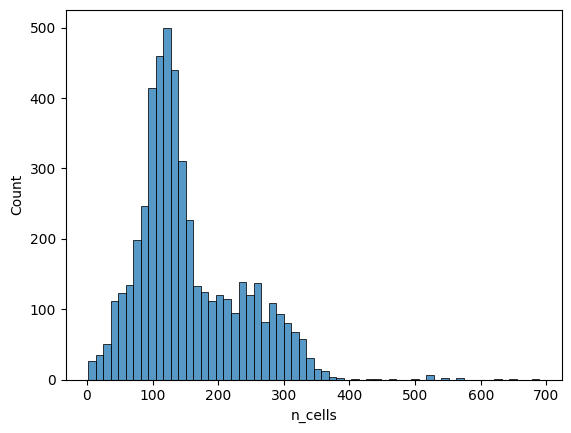

In [11]:
sns.histplot(an.obs.n_cells)

In [12]:
a0 = an[an.obs.drugname_drugconc!='nan_nan'].copy()

/home/icb/manuel.gander/miniconda3/envs/seacells/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<Axes: xlabel='n_cells', ylabel='Count'>

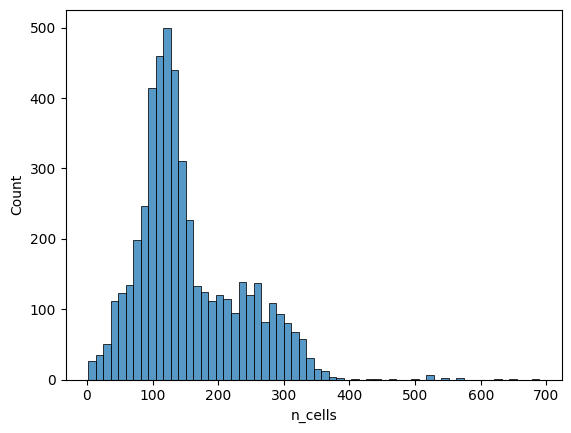

In [13]:
sns.histplot(a0.obs.n_cells)

In [14]:
a0.write('/lustre/groups/ml01/workspace/manuel.gander/sciplex/bulked.h5ad')